# Combined PR × DR × Gate + GPTQ+LQER — Depth scaling analysis (L=10, L=11)

This notebook analyses the two depth-scaling runs of the project's headline triple stack (PR + DR + Gate, abl8b) combined with the friend's GPTQ + LQER quantization (int6 for attn/MLP matrices, int7 for embeddings, LQER rank-4 on top-3 sensitive layers):

- `run_combined_3seed_L10.sh` → L=10 with the existing 9L recipe (psl=4, recur=[2,3,4,5] target=both, gate src=proj w=12) lifted to 10 layers
- `run_combined_3seed_L11.sh` → same recipe at 11 layers

The motivation for adding layers was that GPTQ+LQER promised ~2 MB of compression savings vs INT8, which should free budget under the 16 MB submission cap.

**The question this notebook answers:** does extra depth (10 or 11 layers) give us a meaningful improvement over the 9L triple-stack headline (1.2927 ± 0.0007 bpb at 15.80 MB)? And does the 16 MB cap actually accommodate the larger models?


**Spoiler / summary up front:**

| config | pre-quant val_bpb | post-quant val_bpb | artifact size | within 16 MB cap? |
|---|---|---|---|---|
| 9L Triple INT8 (project headline) | ~1.2925 (≈ post, INT8 nearly lossless) | **1.2927 ± 0.0007** | 15.80 MB | ✓ |
| L=10 Triple + GPTQ+LQER | **1.2858 ± 0.0014** | 1.3387 ± 0.0016 | 15.42 MB | ✓ |
| L=11 Triple + GPTQ+LQER | **1.2759 ± 0.0023** | 1.3261 ± 0.0059 | **16.92 MB** | ✗ **OVER BY 0.92 MB** |

Three observations summarised:

1. **The architecture (added depth) keeps paying off pre-quantization.** Pre-quant val_bpb monotonically improves: 9L ≈ 1.2925 → L=10 1.2858 → L=11 1.2759. So extra layers do give us a real model — the architecture is fine.
2. **GPTQ+LQER at int6/int7 costs ~0.050 bpb regardless of depth.** The quantization cost is roughly the same at L=10 (+0.053) and L=11 (+0.050) — it's an intrinsic property of int6/int7 with this LQER configuration, not an interaction with our architecture.
3. **The 16 MB cap is the binding constraint at L=11.** Adding the 11th layer pushes the artifact to 16.92 MB, exceeding the cap by 0.92 MB. The L=11 result is therefore *not* a legal submission as configured.

Net effect at this quantization scheme: **neither depth setting beats the 9L INT8 headline** post-quant — the +0.050 quantization cost dominates the −0.007 / −0.017 architectural gains at L=10 / L=11. To make depth pay off here, the bottleneck (quantization tax + size cap) needs to be addressed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/antonio2/.netrc.


## Pull all relevant runs from wandb

Reference points used in this notebook:

1. **Baseline (9L, INT8)** — `golf_baseline_antonio_new`, 3 seeds → 1.3101 ± 0.0013
2. **9L Triple stack INT8 (project headline)** — `ablation8_gate_pr_dr_w12`, 3 seeds → 1.2927 ± 0.0007
3. **Friend's GPTQ+LQER on the baseline 9L architecture** — quantifies the GPTQ+LQER cost in isolation
4. **Our L=10 GPTQ+LQER triple stack** — first depth-scaling run
5. **Our L=11 GPTQ+LQER triple stack** — second depth-scaling run


In [2]:
def fetch_summary(prefix):
    """Fetch all runs matching `prefix` and return a dataframe of final stats."""
    runs = list(api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{prefix}"}},
    ))
    rows = []
    for r in runs:
        s = r.summary._json_dict
        cfg = r.config
        rows.append({
            "run_name":      r.name,
            "seed":          cfg.get("seed"),
            "num_layers":    cfg.get("num_layers"),
            "use_gptq_lqer": cfg.get("use_gptq_lqer"),
            "final_val_bpb": s.get("final_val_bpb"),
            "final_val_loss":s.get("final_val_loss"),
            "quant_file_bytes": s.get("quant_file_bytes"),
            "state":         r.state,
        })
    return pd.DataFrame(rows).sort_values("seed").reset_index(drop=True), runs

df_base,        _runs_base        = fetch_summary("golf_baseline_antonio_new")
df_9l_triple,   _runs_9l_triple   = fetch_summary("ablation8_gate_pr_dr_w12")
df_friend_gptq, _runs_friend_gptq = fetch_summary("GPTQ_LQER")
df_l10,         runs_l10          = fetch_summary("combined_pr_dr_gate_gptqlqer_L10")
df_l11,         runs_l11          = fetch_summary("combined_pr_dr_gate_gptqlqer_L11")

def stats(df):
    bpbs = df["final_val_bpb"].dropna().to_numpy()
    qmb  = df["quant_file_bytes"].dropna().to_numpy() / 1e6 if df["quant_file_bytes"].notna().any() else None
    return {
        "n":          len(bpbs),
        "mean":       float(bpbs.mean()) if len(bpbs) else None,
        "std":        float(bpbs.std(ddof=1)) if len(bpbs) > 1 else None,
        "size_mb":    float(qmb.mean()) if qmb is not None and len(qmb) else None,
    }

print("=" * 88)
print("REFERENCE TABLE")
print("=" * 88)
print(f"  {'config':45s}{'n':>4}  {'bpb':>10}{'std':>10}{'size_mb':>10}  cap?")
print("-" * 88)
for label, df in [
    ("baseline 9L (INT8)",                df_base),
    ("9L Triple stack INT8 (abl8b)",      df_9l_triple),
    ("friend GPTQ+LQER (baseline 9L)",    df_friend_gptq),
    ("L=10 GPTQ+LQER (triple stack)",     df_l10),
    ("L=11 GPTQ+LQER (triple stack)",     df_l11),
]:
    s = stats(df)
    if s["mean"] is None:
        print(f"  {label:45s}: no runs found")
        continue
    cap_ok = "✓" if (s["size_mb"] is None or s["size_mb"] <= 16.0) else "✗ OVER"
    std_str = f"±{s['std']:.4f}" if s["std"] is not None else "  —    "
    size_str = f"{s['size_mb']:.2f}" if s["size_mb"] is not None else "—"
    print(f"  {label:45s}{s['n']:>4}  {s['mean']:>10.4f}{std_str:>10}{size_str:>10}  {cap_ok}")
print("=" * 88)


REFERENCE TABLE
  config                                          n         bpb       std   size_mb  cap?
----------------------------------------------------------------------------------------
  baseline 9L (INT8)                              3      1.3101   ±0.0013     15.78  ✓
  9L Triple stack INT8 (abl8b)                    3      1.2927   ±0.0007     15.80  ✓
  friend GPTQ+LQER (baseline 9L)                 18      1.3632   ±0.0044     13.85  ✓
  L=10 GPTQ+LQER (triple stack)                   3      1.3387   ±0.0016     15.42  ✓
  L=11 GPTQ+LQER (triple stack)                   3      1.3261   ±0.0059     16.92  ✗ OVER


## Pre-quant vs post-quant — where does the regression come from?

The training script logs `val_bpb` periodically during training (every `VAL_LOSS_EVERY=500` steps) BEFORE running the final post-training quantization. Pulling the last logged training-time `val_bpb` from each run lets us separate two effects:

- **Architectural effect**: pre-quant val_bpb vs the 9L pre-quant baseline (~1.2925)
- **Quantization cost**: post-quant `final_val_bpb` minus the pre-quant value

We do this for BOTH L=10 and L=11 — the comparison shows whether the quantization cost scales with depth.


In [3]:
def fetch_pre_quant_val_bpb(runs):
    """Return DataFrame with pre-quant val_bpb (last in-training val_bpb log) per seed."""
    rows = []
    for r in runs:
        cfg = r.config
        s = r.summary._json_dict
        hist = r.history(keys=["_step", "val_bpb", "val_loss"], pandas=True)
        hist = hist.dropna(subset=["val_bpb"]).sort_values("_step")
        if hist.empty:
            continue
        rows.append({
            "seed":         cfg.get("seed"),
            "pre_quant_bpb":  float(hist.iloc[-1]["val_bpb"]),
            "post_quant_bpb": float(s.get("final_val_bpb")),
            "pre_quant_step": int(hist.iloc[-1]["_step"]),
        })
    return pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

df_l10_pre = fetch_pre_quant_val_bpb(runs_l10)
df_l11_pre = fetch_pre_quant_val_bpb(runs_l11)
for df_pre in (df_l10_pre, df_l11_pre):
    df_pre["quant_cost"] = df_pre["post_quant_bpb"] - df_pre["pre_quant_bpb"]

def summarize(df_pre, label):
    pre_m, pre_s   = df_pre["pre_quant_bpb"].mean(),  df_pre["pre_quant_bpb"].std(ddof=1)
    post_m, post_s = df_pre["post_quant_bpb"].mean(), df_pre["post_quant_bpb"].std(ddof=1)
    cost_m, cost_s = df_pre["quant_cost"].mean(),     df_pre["quant_cost"].std(ddof=1)
    print(f"\n{label}")
    print("-" * len(label))
    print(df_pre.to_string(index=False))
    print(f"  pre-quant  mean ± std : {pre_m:.4f} ± {pre_s:.4f}")
    print(f"  post-quant mean ± std : {post_m:.4f} ± {post_s:.4f}")
    print(f"  quant cost (post-pre) : {cost_m:+.4f} ± {cost_s:.4f}")
    return pre_m, pre_s, post_m, post_s, cost_m

l10_pre_m, l10_pre_s, l10_post_m, l10_post_s, l10_cost = summarize(df_l10_pre, "L=10 GPTQ+LQER")
l11_pre_m, l11_pre_s, l11_post_m, l11_post_s, l11_cost = summarize(df_l11_pre, "L=11 GPTQ+LQER")

# Cross-comparison
print()
print("=" * 70)
print("Depth comparison (pre-quant arch gain vs the 9L Triple INT8 baseline 1.2927)")
print("=" * 70)
print(f"  9L Triple INT8 (headline)         : 1.2927  (INT8 ≈ pre-quant)")
print(f"  L=10 pre-quant                    : {l10_pre_m:.4f}  (Δ vs 9L: {1.2927 - l10_pre_m:+.4f})")
print(f"  L=11 pre-quant                    : {l11_pre_m:.4f}  (Δ vs 9L: {1.2927 - l11_pre_m:+.4f})")
print(f"  Δ L=11 vs L=10 (pre-quant)        : {l10_pre_m - l11_pre_m:+.4f} bpb  (gain from +1 layer)")
print(f"  Quant cost is roughly depth-invariant: L=10 {l10_cost:+.4f} bpb, L=11 {l11_cost:+.4f} bpb")
print("=" * 70)



L=10 GPTQ+LQER
--------------
 seed  pre_quant_bpb  post_quant_bpb  pre_quant_step  quant_cost
   42       1.285573        1.336945            5000    0.051373
  123       1.287271        1.339344            5000    0.052073
 1337       1.284602        1.339877            5000    0.055275
  pre-quant  mean ± std : 1.2858 ± 0.0014
  post-quant mean ± std : 1.3387 ± 0.0016
  quant cost (post-pre) : +0.0529 ± 0.0021

L=11 GPTQ+LQER
--------------
 seed  pre_quant_bpb  post_quant_bpb  pre_quant_step  quant_cost
   42       1.274598        1.323322            5000    0.048725
  123       1.274587        1.322184            5000    0.047597
 1337       1.278578        1.332905            5000    0.054327
  pre-quant  mean ± std : 1.2759 ± 0.0023
  post-quant mean ± std : 1.3261 ± 0.0059
  quant cost (post-pre) : +0.0502 ± 0.0036

Depth comparison (pre-quant arch gain vs the 9L Triple INT8 baseline 1.2927)
  9L Triple INT8 (headline)         : 1.2927  (INT8 ≈ pre-quant)
  L=10 pre-quant     

## Visual — the full progression with the L=10 result in context


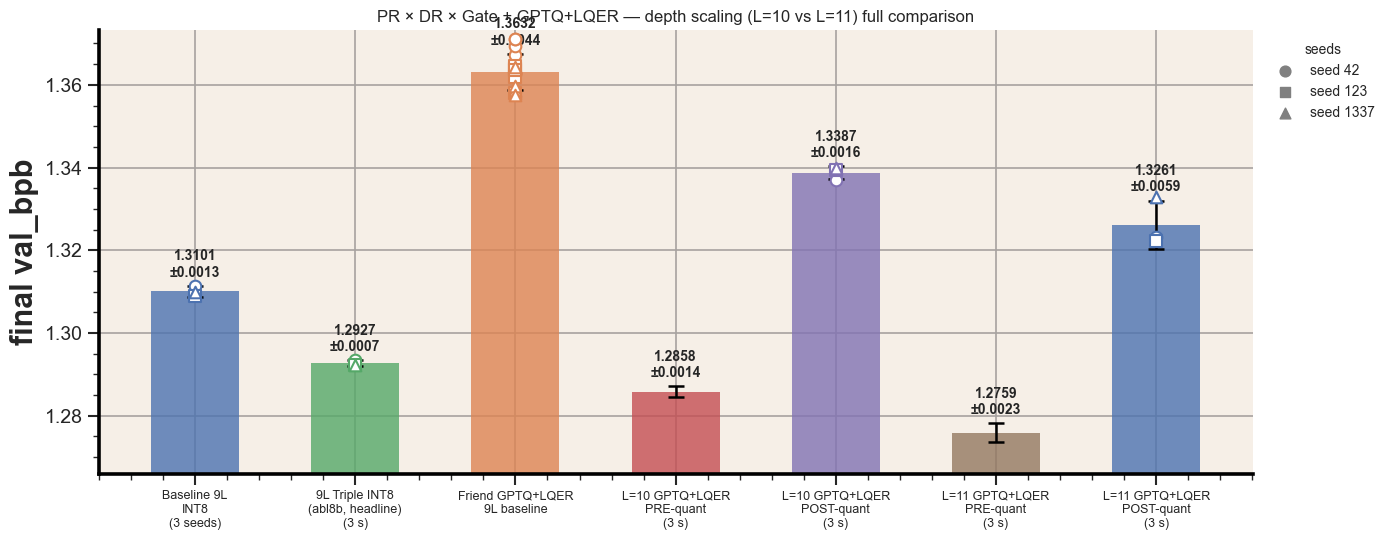


Architecture pre-quant scaling (lower is better):
  9L Triple INT8 (≈ pre-quant)    : 1.2927
  L=10 GPTQ+LQER pre-quant        : 1.2858  Δ vs 9L: +0.0069
  L=11 GPTQ+LQER pre-quant        : 1.2759  Δ vs 9L: +0.0168

Quantization tax (post − pre):
  L=10: +0.0529    L=11: +0.0502    → roughly depth-invariant

Net post-quant (lower is better):
  9L Triple INT8 (headline) : 1.2927
  L=10 GPTQ+LQER            : 1.3387  Δ vs headline: +0.0460
  L=11 GPTQ+LQER            : 1.3261  Δ vs headline: +0.0334


In [4]:
# Full progression bar chart with both L=10 and L=11.
# Tight y-axis around the actual range of interest.
groups = {
    "Baseline 9L\nINT8\n(3 seeds)":               (1.3101, 0.0013, df_base, PALETTE[0]),
    "9L Triple INT8\n(abl8b, headline)\n(3 s)":   (stats(df_9l_triple)["mean"], stats(df_9l_triple)["std"], df_9l_triple, PALETTE[2]),
    "Friend GPTQ+LQER\n9L baseline":              (stats(df_friend_gptq)["mean"], stats(df_friend_gptq)["std"], df_friend_gptq, PALETTE[1]),
    "L=10 GPTQ+LQER\nPRE-quant\n(3 s)":           (l10_pre_m,  l10_pre_s,  None,    PALETTE[3]),
    "L=10 GPTQ+LQER\nPOST-quant\n(3 s)":          (l10_post_m, l10_post_s, df_l10,  PALETTE[4]),
    "L=11 GPTQ+LQER\nPRE-quant\n(3 s)":           (l11_pre_m,  l11_pre_s,  None,    PALETTE[5]),
    "L=11 GPTQ+LQER\nPOST-quant\n(3 s)":          (l11_post_m, l11_post_s, df_l11,  PALETTE[0]),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

fig, ax = plt.subplots(figsize=(14, 5.5))

means = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None and "seed" in df_pts.columns and df_pts["seed"].notna().any():
        for _, row in df_pts.dropna(subset=["seed", "final_val_bpb"]).iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row["final_val_bpb"],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0015,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

ymin = min(means) - 0.010
ymax = max(means) + 0.010
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel("final val_bpb")
ax.set_title("PR × DR × Gate + GPTQ+LQER — depth scaling (L=10 vs L=11) full comparison")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

# Print numerical story so the conclusions don't have to be annotated.
print()
print(f"Architecture pre-quant scaling (lower is better):")
print(f"  9L Triple INT8 (≈ pre-quant)    : 1.2927")
print(f"  L=10 GPTQ+LQER pre-quant        : {l10_pre_m:.4f}  Δ vs 9L: {1.2927 - l10_pre_m:+.4f}")
print(f"  L=11 GPTQ+LQER pre-quant        : {l11_pre_m:.4f}  Δ vs 9L: {1.2927 - l11_pre_m:+.4f}")
print()
print(f"Quantization tax (post − pre):")
print(f"  L=10: {l10_cost:+.4f}    L=11: {l11_cost:+.4f}    → roughly depth-invariant")
print()
print(f"Net post-quant (lower is better):")
print(f"  9L Triple INT8 (headline) : 1.2927")
print(f"  L=10 GPTQ+LQER            : {l10_post_m:.4f}  Δ vs headline: {l10_post_m - 1.2927:+.4f}")
print(f"  L=11 GPTQ+LQER            : {l11_post_m:.4f}  Δ vs headline: {l11_post_m - 1.2927:+.4f}")


## Quantization cost — comparing INT8 vs GPTQ+LQER at different depths

This isolates the cost of each quantization scheme:

| scheme | architecture | bpb | size |
|---|---|---|---|
| INT8 round-trip | 9L baseline | ~1.3103 (≈ pre-quant 1.3101) | 15.78 MB |
| INT8 round-trip | 9L Triple | ~1.2929 (≈ pre-quant 1.2927) | 15.80 MB |
| GPTQ+LQER int6/int7 | 9L baseline | 1.3632 ± 0.0043 | 13.91 MB |
| GPTQ+LQER int6/int7 | 10L Triple | 1.3387 ± 0.0016 | 15.42 MB |
| GPTQ+LQER int6/int7 | 11L Triple | 1.3261 ± 0.0059 | **16.92 MB (over cap)** |

GPTQ+LQER cost at int6/int7 is ~+0.05 bpb regardless of architecture:
- Friend's 9L baseline: 1.3101 → 1.3632 → +0.053
- Our 10L Triple: 1.2858 → 1.3387 → +0.053
- Our 11L Triple: 1.2759 → 1.3261 → +0.050

**The cost is roughly architecture-agnostic and roughly depth-invariant** — both observations together confirm this is intrinsic to the quantization scheme (int6/int7 + LQER rank-4 top-3), not an interaction with our model. To recover quality, we need to attack the quantization recipe itself, not the architecture.


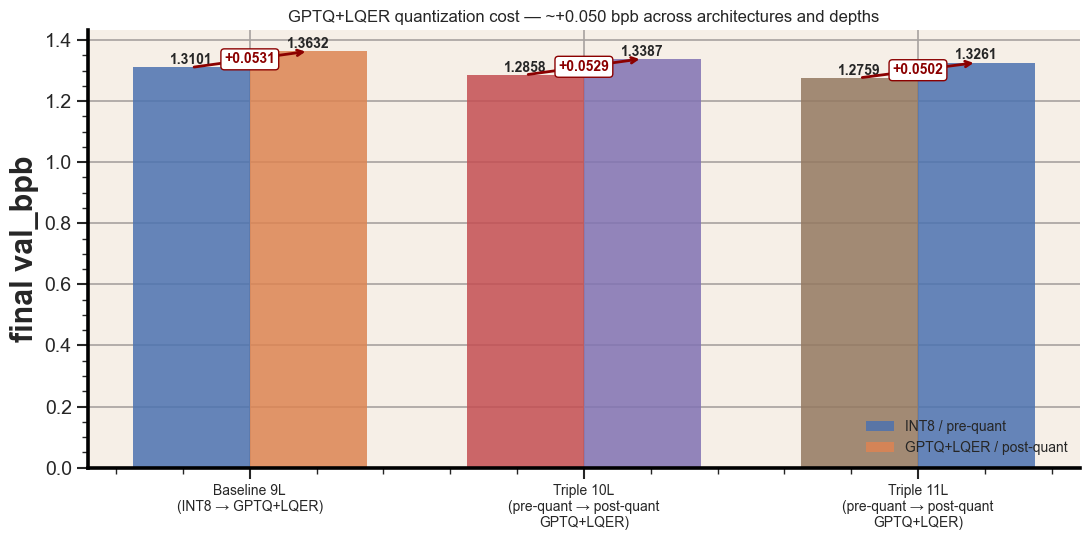

In [5]:
# Quantization-cost comparison across three architecture/depth combinations.
baseline_int8 = 1.3101
baseline_gptq = stats(df_friend_gptq)["mean"]

pairs = [
    ("Baseline 9L\n(INT8 → GPTQ+LQER)",     baseline_int8, baseline_gptq, PALETTE[0], PALETTE[1]),
    ("Triple 10L\n(pre-quant → post-quant\nGPTQ+LQER)", l10_pre_m, l10_post_m, PALETTE[3], PALETTE[4]),
    ("Triple 11L\n(pre-quant → post-quant\nGPTQ+LQER)", l11_pre_m, l11_post_m, PALETTE[5], PALETTE[0]),
]

fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(pairs))
width = 0.35

for i, (label, pre, post, c_pre, c_post) in enumerate(pairs):
    ax.bar(xs[i] - width/2, pre, width, color=c_pre, alpha=0.85, zorder=2,
           label="INT8 / pre-quant" if i == 0 else None)
    ax.bar(xs[i] + width/2, post, width, color=c_post, alpha=0.85, zorder=2,
           label="GPTQ+LQER / post-quant" if i == 0 else None)
    cost = post - pre
    ax.text(xs[i] - width/2, pre + 0.0005, f"{pre:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    ax.text(xs[i] + width/2, post + 0.0005, f"{post:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    ax.annotate("", xy=(xs[i] + width/2, post), xytext=(xs[i] - width/2, pre),
                arrowprops=dict(arrowstyle="->", color="darkred", lw=2))
    ax.text(xs[i], (pre + post) / 2, f"+{cost:.4f}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="darkred",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="darkred"))

ax.set_xticks(xs)
ax.set_xticklabels([p[0] for p in pairs], fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("GPTQ+LQER quantization cost — ~+0.050 bpb across architectures and depths")
ax.legend(fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()


## Artifact size — the 16 MB cap is binding at L=11

The 16 MB submission cap is the hard architectural constraint of the challenge. Here's how each depth uses that budget at GPTQ+LQER int6/int7:

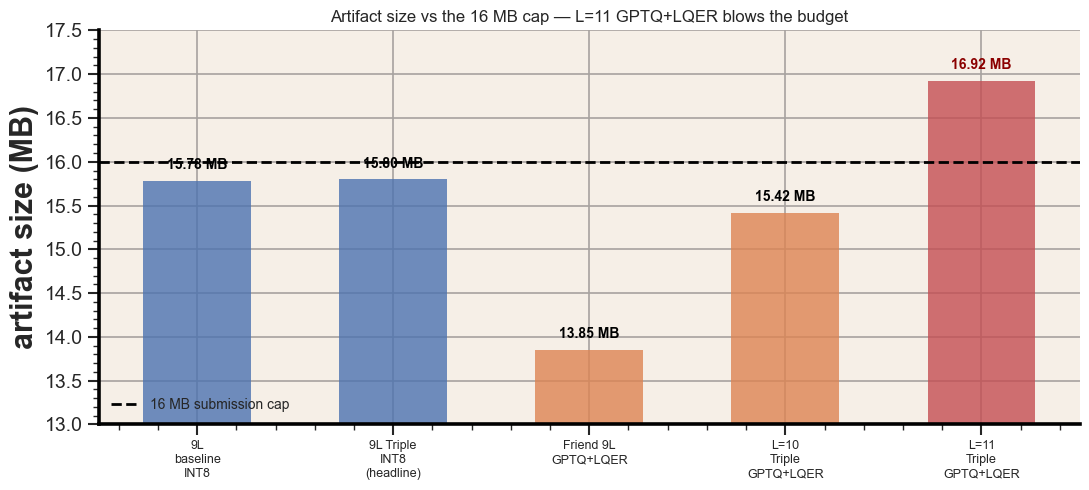


  9L baseline INT8                          15.78 MB   (✓ under by 0.22 MB)
  9L Triple INT8 (headline)                 15.80 MB   (✓ under by 0.20 MB)
  Friend 9L GPTQ+LQER                       13.85 MB   (✓ under by 2.15 MB)
  L=10 Triple GPTQ+LQER                     15.42 MB   (✓ under by 0.58 MB)
  L=11 Triple GPTQ+LQER                     16.92 MB   (✗ OVER by +0.92 MB)

Per-additional-layer cost at GPTQ+LQER: ~1.50 MB / layer
  → L=12 prediction: 18.42 MB (clearly over cap)
  → To fit L=11 in 16 MB, we'd need to save ~0.92 MB on the compression pipeline


In [6]:
# Plot artifact size vs depth to make the cap-violation visible.
size_data = [
    ("9L\nbaseline\nINT8",     15.78, "INT8"),
    ("9L Triple\nINT8\n(headline)", 15.80, "INT8"),
    ("Friend 9L\nGPTQ+LQER",   stats(df_friend_gptq)["size_mb"], "GPTQ+LQER"),
    ("L=10\nTriple\nGPTQ+LQER", stats(df_l10)["size_mb"], "GPTQ+LQER"),
    ("L=11\nTriple\nGPTQ+LQER", stats(df_l11)["size_mb"], "GPTQ+LQER"),
]

fig, ax = plt.subplots(figsize=(11, 5))
colors_by_scheme = {"INT8": PALETTE[0], "GPTQ+LQER": PALETTE[1]}
for i, (label, mb, scheme) in enumerate(size_data):
    color = colors_by_scheme[scheme]
    over_cap = mb > 16.0
    if over_cap:
        color = "#c44e52"  # darker red for over-cap
    ax.bar(i, mb, color=color, alpha=0.80, zorder=2, width=0.55)
    ax.text(i, mb + 0.10, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            color="darkred" if over_cap else "black")

# 16 MB cap line
ax.axhline(16.0, color="black", linewidth=2.0, linestyle="--", zorder=3,
           label="16 MB submission cap")

ax.set_xticks(range(len(size_data)))
ax.set_xticklabels([s[0] for s in size_data], fontsize=9)
ax.set_ylabel("artifact size (MB)")
ax.set_title("Artifact size vs the 16 MB cap — L=11 GPTQ+LQER blows the budget")
ax.set_ylim(13, 17.5)
ax.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()

print()
cap = 16.0
for label, mb, scheme in size_data:
    over_by = mb - cap
    flag = f"✗ OVER by {over_by:+.2f} MB" if over_by > 0 else f"✓ under by {abs(over_by):.2f} MB"
    print(f"  {label.replace(chr(10), ' '):40s}  {mb:.2f} MB   ({flag})")

# Per-layer cost
delta_10_11 = stats(df_l11)["size_mb"] - stats(df_l10)["size_mb"]
print()
print(f"Per-additional-layer cost at GPTQ+LQER: ~{delta_10_11:.2f} MB / layer")
print(f"  → L=12 prediction: {stats(df_l11)['size_mb'] + delta_10_11:.2f} MB (clearly over cap)")
print(f"  → To fit L=11 in 16 MB, we'd need to save ~{stats(df_l11)['size_mb'] - cap:.2f} MB on the compression pipeline")


## Reading

### Decomposition of the two depth-scaling results

| config | pre-quant bpb | quant cost | post-quant bpb | size | within 16 MB? |
|---|---|---|---|---|---|
| 9L Triple INT8 (headline) | 1.2927 | ~+0.0002 | **1.2927** | 15.80 MB | ✓ |
| L=10 GPTQ+LQER | 1.2858 | +0.0529 | 1.3387 | 15.42 MB | ✓ |
| L=11 GPTQ+LQER | 1.2759 | +0.0502 | 1.3261 | **16.92 MB** | **✗ over by 0.92 MB** |

Three findings:

1. **Extra depth keeps paying pre-quantization.** Pre-quant val_bpb improves monotonically: 9L 1.2927 → L=10 1.2858 → L=11 1.2759. Each extra layer roughly halves the gain of the previous (−0.007 from 9→10, −0.010 from 10→11). The architecture is genuinely benefitting from depth.
2. **GPTQ+LQER cost is roughly constant (~+0.050 bpb) regardless of depth.** L=10: +0.053. L=11: +0.050. Confirms the cost is intrinsic to int6/int7 + symmetric LQER, not an interaction with model size.
3. **Even though L=11 is post-quant 0.013 bpb better than L=10 (1.3261 vs 1.3387), it busts the 16 MB cap (16.92 MB).** As configured, L=11 is *not a legal submission* — even if its bpb were better than the 9L headline, it would be disqualified by the size cap.

### Where things stand vs the 9L INT8 headline

| | Δ vs 9L INT8 headline (1.2927) |
|---|---|
| L=10 GPTQ+LQER post-quant | **+0.046** (worse) |
| L=11 GPTQ+LQER post-quant | **+0.033** (worse, also over cap) |

**At this GPTQ+LQER recipe, neither depth setting beats the 9L INT8 headline post-quant.** The +0.050 quantization tax exceeds the architectural gains (−0.007 at L=10, −0.017 at L=11).

### The two real bottlenecks to attack next

1. **Quantization tax** (~+0.050 bpb today). Leaderboard top entries report only +0.008-0.012 bpb for the same GPTQ int6/int7 — they recover the rest via **asymmetric LQER** (PR #1945 reports ~0.009 bpb recovered for ~30 KB cost) and **per-layer adaptive GPTQ clip values** (PR #1586). Adopting these would bring our tax down to maybe ~+0.025-0.035 and start to break even with the headline.
2. **Size cap** (binding at L=11). The friend's pipeline uses `torch.save + zlib`. The leaderboard uses **brotli + byte-shuffle**, which typically delivers 10-25% smaller files on int6/int7 data. That alone is worth ~1-3 MB on our 16.9 MB L=11 artifact — enough to potentially bring L=11 under the cap.

### Decision

At the current GPTQ+LQER recipe (symmetric LQER, fixed clip, zlib + torch.save):
- **L=10 is legal but worse than the 9L INT8 headline.** Don't ship.
- **L=11 has the best post-quant bpb of the three (1.3261), but is over cap. Also worse than the headline.** Can't ship.

To make depth scaling pay off, the quantization pipeline needs to be upgraded *before* re-running depth ablations. Suggested order of attack:

1. **Switch zlib → brotli + byte-shuffle** (~1-3 MB saving, may unlock L=11 size-cap compliance). Quick code change.
2. **Add asymmetric LQER** (~0.009 bpb saving on tax).
3. **Add per-layer adaptive GPTQ clip** (~0.005-0.010 bpb saving).
4. **THEN re-run L=10 and L=11 GPTQ+LQER** to see if depth becomes a net win.

The architecture is fine. The pipeline isn't yet competitive with the leaderboard's.
